In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv(r'c:\Users\ayubi\Downloads\ml-assessment-ayush-kumar\data\q1_heart_disease.csv')

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Value counts:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
df.head()


Dataset Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Value counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


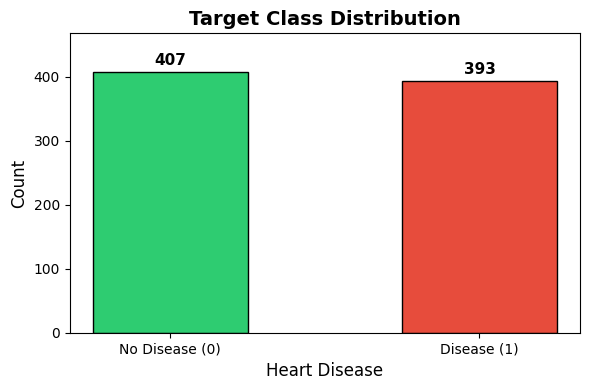

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['heart_disease'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
                 color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax.bar_label(bars, fmt='%d', padding=3, fontsize=11, fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Heart Disease', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()

# **Interpretation:** The dataset is roughly balanced between patients with and without heart disease,
# This balance is favourable for classification, we don't need aggressive resampling techniques, though stratified splitting is still good practice.

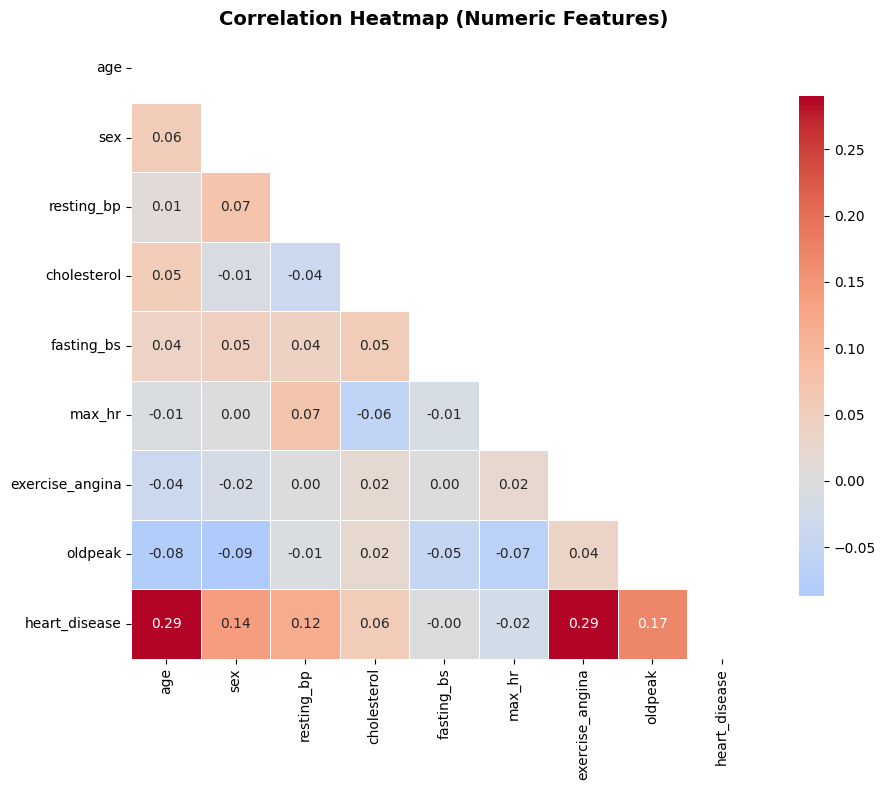

In [3]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()
 
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png', dpi=150)
plt.show()


# **Interpretation:** `heart_disease` shows positive correlation with `age` and `exercise_angina`, indicating older patients and those who experience angina during exercise are strongly associated with heart disease
# and negative correlation with `max_hr` — patients with lower max heart rate tend to have disease.
# `cholestrol` and `resting_bp` are moderately positively correlated, which is physiologically expected.

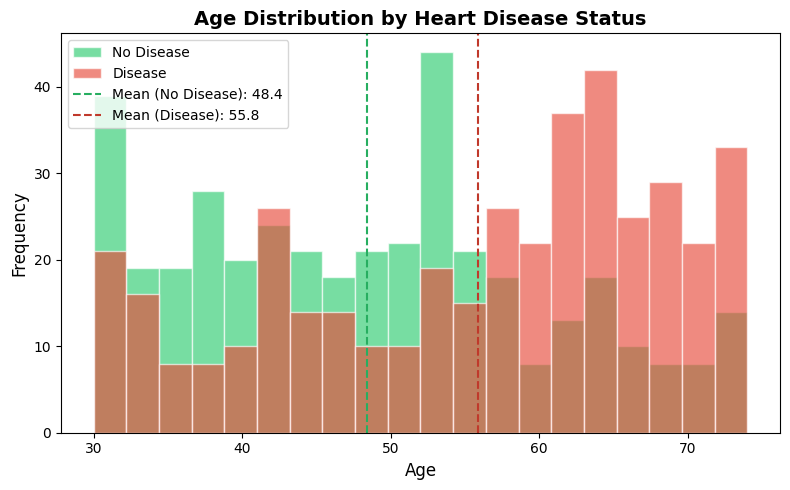

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['heart_disease'] == label]['age']
    ax.hist(subset, bins=20, alpha=0.65, color=color,
            label=f'{"No Disease" if label == 0 else "Disease"}', edgecolor='white')
ax.axvline(df[df['heart_disease'] == 0]['age'].mean(), color='#27ae60',
           linestyle='--', linewidth=1.5, label=f'Mean (No Disease): {df[df["heart_disease"]==0]["age"].mean():.1f}')
ax.axvline(df[df['heart_disease'] == 1]['age'].mean(), color='#c0392b',
           linestyle='--', linewidth=1.5, label=f'Mean (Disease): {df[df["heart_disease"]==1]["age"].mean():.1f}')
ax.set_title('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('plot3_age_distribution.png', dpi=150)
plt.show()

# **Interpretation:** Patients with heart disease tend to be slightly older on average.
# However, both groups span a wide age range, confirming that age alone is insufficient for diagnosis — the model needs multiple features.

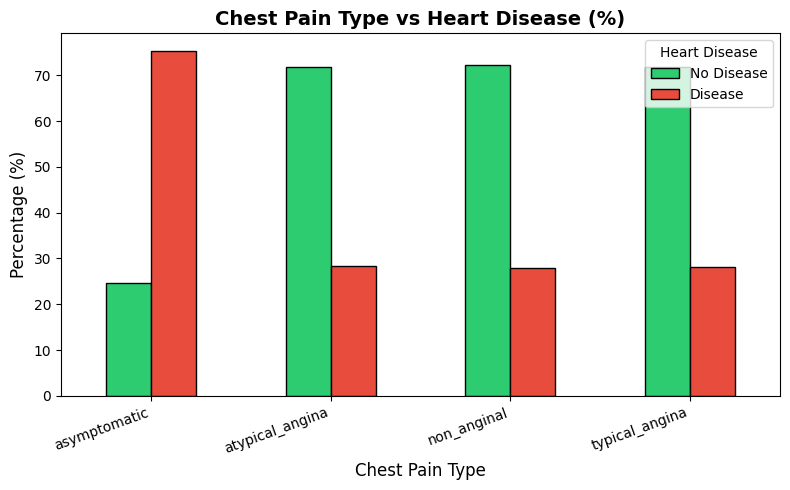

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df['chest_pain_type'], df['heart_disease'], normalize='index') * 100
ct.columns = ['No Disease', 'Disease']
ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Chest Pain Type vs Heart Disease (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Chest Pain Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Heart Disease')
plt.tight_layout()
plt.savefig('plot4_chest_pain_disease.png', dpi=150)
plt.show()

# **Interpretation:** Asymptomatic chest pain is strongly associated with heart disease — a counterintuitive
# but well-documented clinical finding. Typical angina shows the lowest disease rate.
# This makes`chest_pain_type` one of the most informative categorical features for the model.

In [6]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:
resting_bp     24
cholesterol    32
dtype: int64


# **Strategy:** We use **median imputation** for the two numeric columns with missing values
# (`resting_bp`, `cholesterol`). 
# Median is preferred over mean because it is robust to the outliers present in physiological measurements.
#  Row dropping is avoided to preserve the already-limited dataset size.

In [7]:
for col in ['resting_bp', 'cholesterol', 'max_hr']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  Imputed '{col}' with median = {median_val:.1f}")
 
print("\nMissing values after imputation:")
print(df.isnull().sum())

  Imputed 'resting_bp' with median = 130.0
  Imputed 'cholesterol' with median = 247.0
  Imputed 'max_hr' with median = 149.0

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


In [8]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")
 
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
print(f"Shape after one-hot encoding: {df_encoded.shape}")


Categorical columns to encode: ['chest_pain_type', 'resting_ecg', 'st_slope']
Shape after one-hot encoding: (800, 19)


C:\Users\ayubi\AppData\Local\Temp\ipykernel_15964\3106853239.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [9]:
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train size: 640, Test size: 160
Train class balance:
heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64
Test class balance:
heart_disease
1    0.506
0    0.494
Name: proportion, dtype: float64


In [10]:
numerical_cols = df.select_dtypes(include='number').drop(columns='heart_disease').columns.tolist()
# Map original numeric col names to encoded df col names (they are unchanged)
num_cols_in_encoded = [c for c in numerical_cols if c in X_train.columns]
 
scaler = StandardScaler()
X_train[num_cols_in_encoded] = scaler.fit_transform(X_train[num_cols_in_encoded])
X_test[num_cols_in_encoded]  = scaler.transform(X_test[num_cols_in_encoded])
 
print("\nPreprocessing complete. Feature matrix shape:", X_train.shape)


Preprocessing complete. Feature matrix shape: (640, 18)


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
 
# Fix random_state=42 for all models
models = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}
 
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"  ✔  {name} trained.")

  ✔  Decision Tree trained.
  ✔  Random Forest trained.
  ✔  Gradient Boosting trained.


 Model: Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

 Model: Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

 Model: Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77     

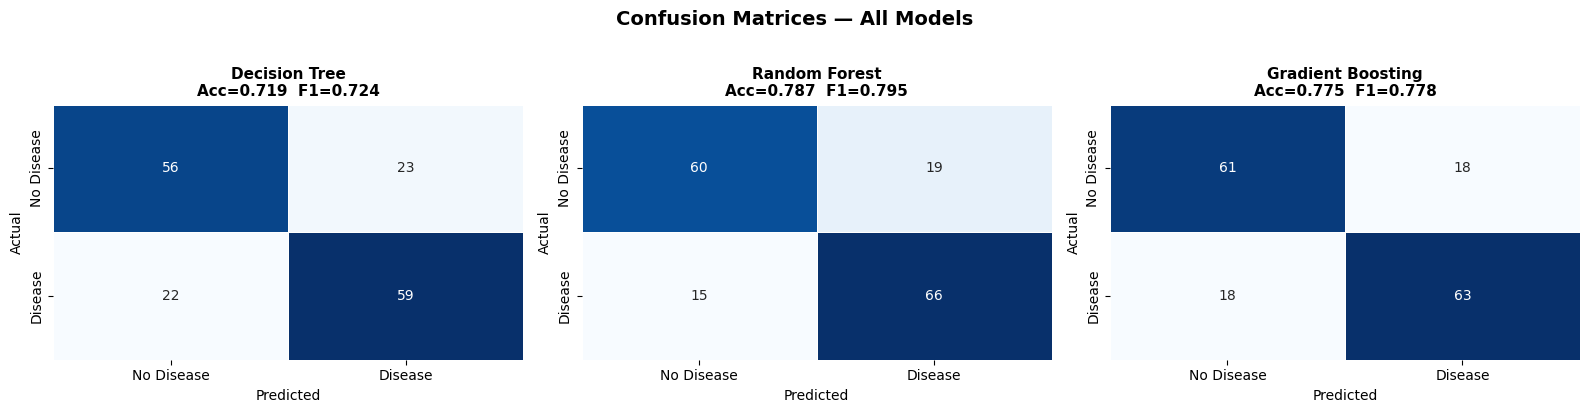

In [12]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
 
results = {}
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    
    # ---- Metrics ----
    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    accuracy  = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy':  accuracy,
        'Precision': precision,
        'Recall':    recall,
        'F1-Score':  f1,
        'y_pred':    y_pred,
    }
    
    print(f" Model: {name}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    
    # ---- Confusion Matrix Plot ----
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAcc={accuracy:.3f}  F1={f1:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
 
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# **Result**: Random Forest achieves the highest F1-Score(0.7952) outperforming other models.
# F1-Score is the primary metric.
# In medical diagnosis, both types of classification errors carry real costs. A False Negative (predicting no disease when disease is present) means a sick patient goes untreated, a potentially life-threatening outcome. A False Positive (predicting disease when none exists) leads to unnecessary investigations and patient anxiety
# F1-Score is the harmonic mean of Precision and Recall, penalising both error types equally, making it more appropriate than accuracy alone for this context.

In [13]:
from sklearn.model_selection import GridSearchCV
 
# Dynamically select the best model based on F1-Score
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])
print(f"Best model from Task 5: {best_model_name}")
 
param_grids = {
    'Decision Tree': {
        'max_depth':         [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'criterion':         ['gini', 'entropy'],
    },
    'Random Forest': {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 5, 10],
        'min_samples_split': [2, 5],
    },
    'Gradient Boosting': {
        'n_estimators':      [100, 200, 300],
        'learning_rate':     [0.05, 0.1, 0.2],
        'max_depth':         [3, 4, 5],
    },
}
 
estimator_map = {
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Random Forest':     RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}
 
grid_search = GridSearchCV(
    estimator  = estimator_map[best_model_name],
    param_grid = param_grids[best_model_name],
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1,
)
 
print("Running GridSearchCV — this may take a moment…")
grid_search.fit(X_train, y_train)
 
print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Best CV F1-Score:       {grid_search.best_score_:.4f}")

Best model from Task 5: Random Forest
Running GridSearchCV — this may take a moment…
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters Found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1-Score:       0.8331


In [14]:
best_tuned   = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)
 
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall    = recall_score(y_test, y_pred_tuned)
tuned_f1        = f1_score(y_test, y_pred_tuned)
tuned_accuracy  = accuracy_score(y_test, y_pred_tuned)
 
# Untuned baseline scores
baseline = results[best_model_name]
 
print(f"  Tuned vs Untuned {best_model_name} — Test Set Comparison")
print("="*60)
comparison = pd.DataFrame({
    'Untuned (baseline)': {
        'Accuracy':  baseline['Accuracy'],
        'Precision': baseline['Precision'],
        'Recall':    baseline['Recall'],
        'F1-Score':  baseline['F1-Score'],
    },
    'Tuned (GridSearchCV)': {
        'Accuracy':  tuned_accuracy,
        'Precision': tuned_precision,
        'Recall':    tuned_recall,
        'F1-Score':  tuned_f1,
    }
}).round(4)
print(comparison)

  Tuned vs Untuned Random Forest — Test Set Comparison
           Untuned (baseline)  Tuned (GridSearchCV)
Accuracy               0.7875                0.7812
Precision              0.7765                0.7614
Recall                 0.8148                0.8272
F1-Score               0.7952                0.7929


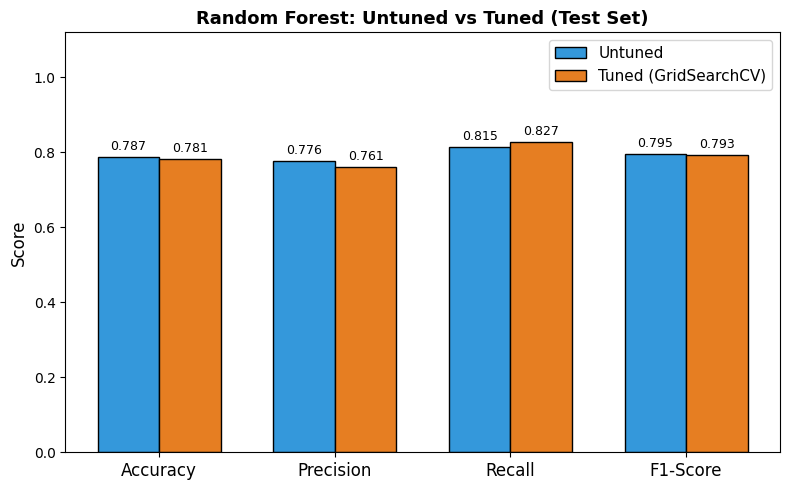

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x       = np.arange(len(metrics))
width   = 0.35
 
baseline_vals = [baseline['Accuracy'], baseline['Precision'],
                 baseline['Recall'],   baseline['F1-Score']]
tuned_vals    = [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1]
 
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Untuned',
               color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, tuned_vals, width, label='Tuned (GridSearchCV)',
               color='#e67e22', edgecolor='black')
 
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'{best_model_name}: Untuned vs Tuned (Test Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('plot6_tuning_comparison.png', dpi=150)
plt.show()